In [21]:
%load_ext autoreload
%autoreload 2

import importlib

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
from draw_rectangles import draw_rect, draw_riemann_rectangles
import solve_integrals as si

sp.init_printing()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Understanding Integrals Through Real-World Applications

## 1. Introduction

Integrals are a mathematical tool for calculating quantities that acumulate or change continuously.
They can be used to find areas, distances, volumes and many other quantities

In physics, engineering, economics, and data science, many real-world quantities change continuously rather than remaining constant.

Integration provides a way to combine these changing quantities into a meaningful total.

### 1.1 An Example: Areas of Simple Shapes

Areas of simple geometric shapes are relatively easy to calculate because their dimensions can be described using known formulas. 

* A rectangle, for example, can be calculated using $A = width \times height$.
* The area of a triangle can be calculated using $A = \frac{1}{2}bh$.

### 1.2 What About the Area Under a Curve

We will investigate the area under the curve $f(x)=x^2$ between $x=0$ and $x=2$.

In other words, we want to calculate the region bounded by the curve, the x-axis, and the two verticals.

* lower boundary: $x = 0$
* upper boundary: $x = 2$
* curve: $f(x) = x^2$
* lower horizontal boundary: $y = 0$




### 1.3 Visualizing the Problem

To better understand the problem, we can visualise the region under the curve $f(x) = x^2$, that we want to calculate.

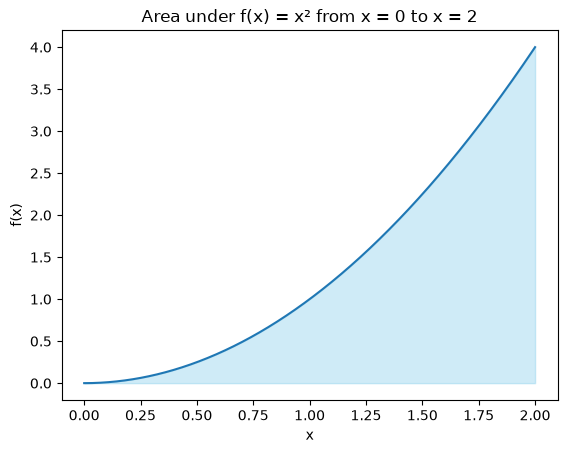

In [22]:

x = np.linspace(0, 2, 1000)

y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area under f(x) = x² from x = 0 to x = 2")
plt.show()





### 1.4 Area Under a Curve

We see that the height changes continuously along the curve:
* At $x = 0$, the height is $0^2 = 0$
* At $x = 1$, the height is $1^2 = 1$
* At $x = 2$, the height is $2^2 = 4$

Therefore, $width * height$ cannot be used directly because there is no single height for the entire region.

Instead, we can approximate the area using shapes whose areas we already know how to calculate. The simple choice is a rectangle.

How can we calculate the area under the curve using rectangles?


## 2. Approximating the Area with Rectangles

### 2.1 Dividing the interval

Let's continue with $y = x^2$ from $x=0$ to $x = 2$

For example - let's use 4 rectangles, the interval length is $2 - 0 = 2$

With 4 rectangles, each rectangle has width $\Delta x = \frac{2}{4} = 0.5$ 

The x values would be $0, 0.5, 1, 1.5, 2$, so we can calculate the heights with $x^2$

### 2.2 Approximating with Rectangles

At first we can approximate the height by using the **left edge** of the rectangle
* First rectangle is in our first interval $0 \leq x \leq 0.5$. 
    * $f(0) = 0^2 = 0$. 
    * $A_1 = 0.5 \times 0 = 0$
* Second rectangle interval $0.5 \leq x \leq 1$. 
    * $f(0.5) = 0.5^2 = 0.25$. 
    * $A_2 = 0.5 \times 0.25 = 0.125$
* Third rectangle interval $1 \leq x \leq 1.5$.
    * $f(1) = 1^2 = 1$. 
    * $A_3 = 0.5 \times 1 = 0.5$
* Fourth rrectangle interval $1.5 \leq x \leq 2$.
    * $f(1) = 1.5^2 = 2.25$. 
    * $A_4 = 0.5 \times 2.25 = 1.125$

Now add them together: $A_L \approx 0 + 0.125 + 0.5 + 1.125 = 1.75$

The estimated area under the curve is $1.75$ square units, but the calculation is not the exact area, its an approximation.

As we can observe, our rectangles do not cover the whole region underneath the curve. There is missing area because $x^2$ is 
increasing over this interval. Using the left edge gives us rectangles that are too short.

Therefore we underestimated the area. 


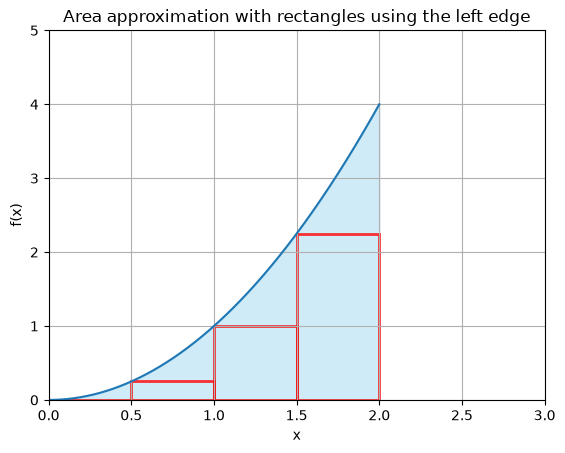

In [23]:

x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

draw_rect(plt.gca(),'r', 0, 0, 0.5, 0)
draw_rect(plt.gca(),'r', 0.5, 0, 0.5, 0.25)
draw_rect(plt.gca(),'r', 1, 0, 0.5, 1)
draw_rect(plt.gca(),'r', 1.5, 0, 0.5, 2.25)

plt.xlim(0, 3)
plt.ylim(0, 5)

plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area approximation with rectangles using the left edge")
plt.show()


### 2.3 Approximate with the right edge

Let's observe what happens when the approximation is done with the right edge of each interval $x$ values would be $0.5, 1, 1.5, 2$

* First rectangle $f(0.5) = 0.25$, so $A_1 = 0.5 \times 0.25 = 0.125$
* Second rectangle $f(1) = 1$, so $A_2 = 0.5 \times 1 = 0.5$
* Third rectangle $f(1.5) = 2.25$, so $A_3 = 0.5 \times 2.25 = 1.125$
* Fourth rectangle $f(2) = 4$, so $A_4 = 0.5 \times 4 = 2$

Total: $A_R \approx  0.125 + 0.5 + 1.125 + 2 = 3.75$

The left-endpoint approximation underestimates the area, while the right-endpoint approximation overestimates it. 

Therefore, the actual area lies somewhere between these two values $1.75 \lt area \lt 3.75$.


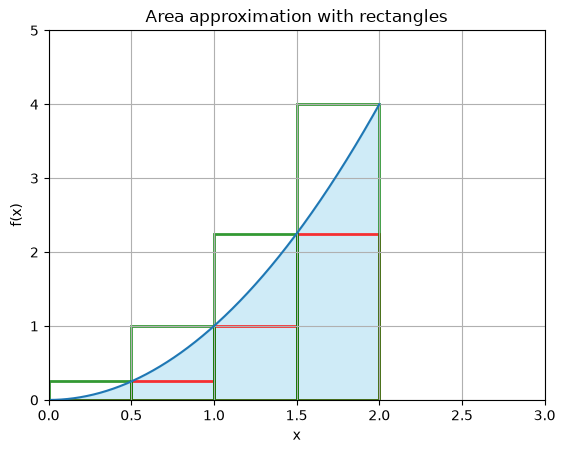

In [24]:
x = np.linspace(0, 2, 1000)
y = x**2

plt.plot(x, y)
plt.fill_between(x, y, color="skyblue", alpha=0.4)

draw_rect(plt.gca(), 'r', 0,   0, 0.5, 0   )
draw_rect(plt.gca(), 'r', 0.5, 0, 0.5, 0.25)
draw_rect(plt.gca(), 'r', 1,   0, 0.5, 1   )
draw_rect(plt.gca(), 'r', 1.5, 0, 0.5, 2.25)

draw_rect(plt.gca(), 'g', 0,   0, 0.5, 0.25)
draw_rect(plt.gca(), 'g', 0.5, 0, 0.5, 1   )
draw_rect(plt.gca(), 'g', 1,   0, 0.5, 2.25)
draw_rect(plt.gca(), 'g', 1.5, 0, 0.5, 4   )

plt.xlim(0, 3)
plt.ylim(0, 5)

plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Area approximation with rectangles")
plt.show()

### 2.4 Riemann Sum

Instead of writing $0.5(0+0.25+1+2.25)$ we can go with:

$$A\approx\sum_{i=1}^{n}f(x_i)\Delta x$$

This type of sum is called a Riemann sum. Where:
* $f(x_i) =$ height of rectangle $i$
* $\Delta x =$ width of the rectangle
* $n =$  number of rectangles

It provides a systematic way of adding the areas of many small rectangles to approximate the area under a curve.

### 2.5 Increasing the Number of Rectangles

Let's observe what happens when we increase the number of rectangles under the curve.

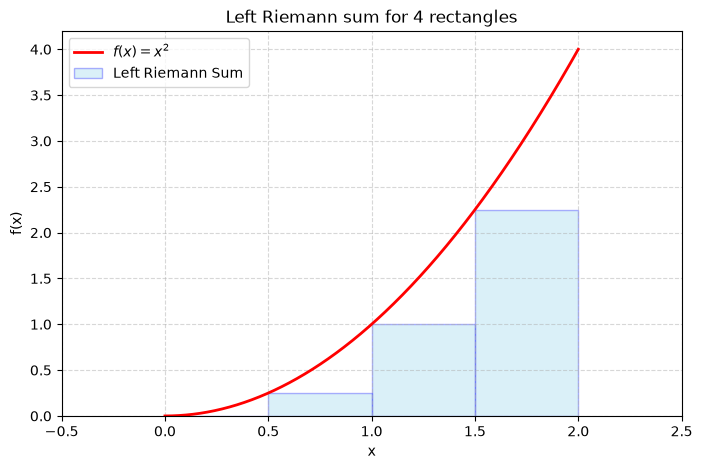

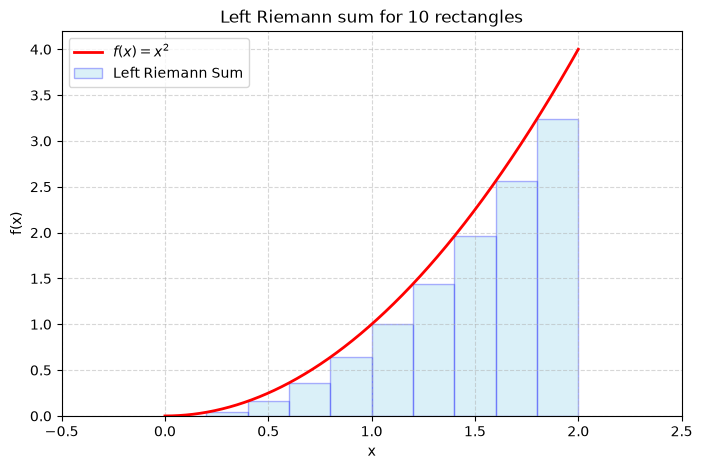

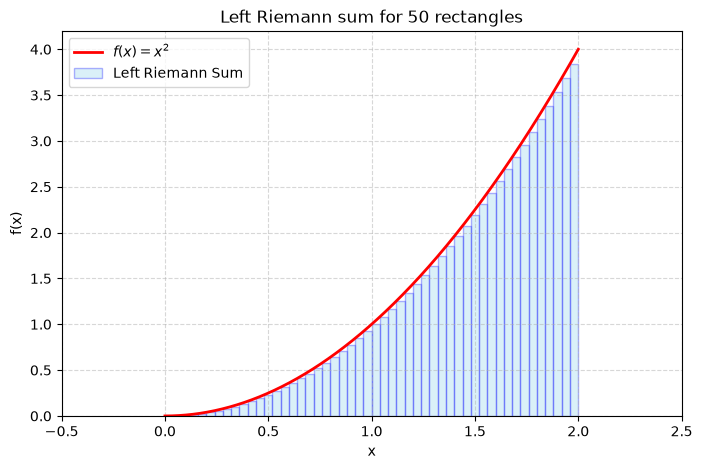

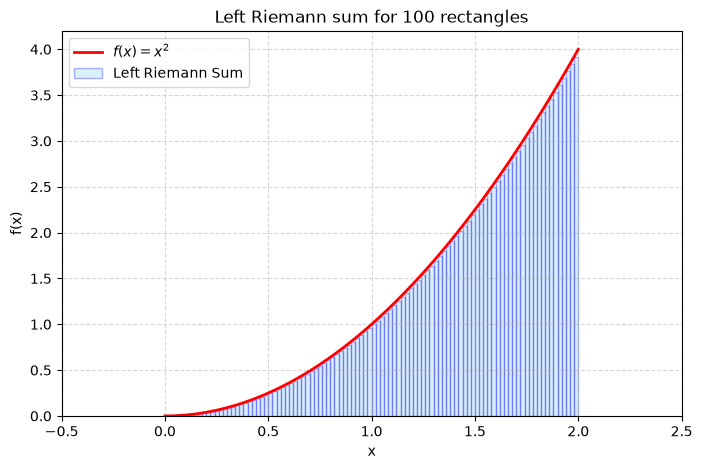

In [25]:
def f(x):
    return x**2

draw_riemann_rectangles(0, 2, 4, f)
draw_riemann_rectangles(0, 2, 10, f)
draw_riemann_rectangles(0, 2, 50, f)
draw_riemann_rectangles(0, 2, 100, f)


We can see that as the number of rectangles increases, their width decreases and they follow the curve more closely.

As a result, the approximation becomes more accurate.

### 2.6 Numerical Approximation with Python

We can also calculate the approximations programmatically using Python.

The following results show how the estimated area changes as the number of rectangles increases.

In [35]:
result_n_4 = si.integrate(si.function_to_integrate, 0, 2, 4)
result_n_10 = si.integrate(si.function_to_integrate, 0, 2, 10)
result_n_100 = si.integrate(si.function_to_integrate, 0, 2, 100)
result_n_1000 = si.integrate(si.function_to_integrate, 0, 2, 1000)
result_n_10000 = si.integrate(si.function_to_integrate, 0, 2, 10000)

data = {
    "Number of rectangles (n)": [4, 10, 100, 1000, 10000],
    "Calculated area": [result_n_4, result_n_10, result_n_100, result_n_1000, result_n_10000]
}
df = pd.DataFrame(data)

df.index = df.index + 1

df.style.format({"Calculated area": "{:.4f}"})

,Number of rectangles (n),Calculated area
1,4,1.7500
2,10,2.2800
3,100,2.6268
4,1000,2.6627
5,10000,2.6663


As the number of rectangles increases, the calculated area gets progressively closer to the actual area.

## 3. From Approximation to the Definite Integral

### 3.1 The Limit of the Approximation

$ \int_a^b f(x)dx = \lim\limits_{n\rightarrow\infty} \sum\limits_{i=1}^{n} f(x_i)\Delta x $

### 3.2 Calculating the integral analytically

## 4. Application 1: From Velocity to Distance

## 5. Application 2: Variable Force and Work

## 6. Application 3: Probability

## 7. Going Beyond One Dimension: Multiple Integrals

## 8. A Real-World Multiple-Integral Application
### Volume of a surface 
$$f(x,y)=4-x^2-y^2$$
over a simple square region, for example:
$$0\leq x\leq2,\qquad 0\leq y\leq2$$
$$V\approx\sum f(x_i,y_j)\Delta x\Delta y$$

## 9. Conclusions
### 9.1 What We Learned
### 9.2 Why Integrals Are Useful
### 9.3 Extensions
* Triple integrals
* Physics
* Engineering
* Statistics
* Economics
* Machine learning / data science